# Phase 2 ML Backtest

End-to-end pipeline: historical data → features → labels → logistic regression training → vectorized backtest → performance metrics.

In [1]:
import sys
import os

# Ensure the repo root is on sys.path when running from notebooks/
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from bot.config import HISTORY_MONTHS, SYMBOL
from bot.data.fetcher import fetch_bars_range
from bot.backtest.engine import run_backtest
from bot.backtest.metrics import compute_metrics
from bot.features.labeling import make_labels
from bot.features.rolling import compute_features
from bot.utils.credentials import load_credentials

## 1. Data

Fetch 6 months of 1-hour OHLCV bars from Alpaca.

In [3]:
api_key, secret_key = load_credentials()

df_raw = fetch_bars_range(api_key, secret_key)
print(f"Fetched {len(df_raw)} bars for {SYMBOL} (last {HISTORY_MONTHS} months)")
df_raw.head()

Credentials loaded.
Fetched 4319 bars for BTC/USD (last 6 months)


,timestamp,open,high,low,close,volume
0,2025-10-21 08:00:00+00:00,108110.5570,108133.712,107584.5360,107771.650,0.082082
1,2025-10-21 09:00:00+00:00,107734.3300,108001.326,107621.0635,107810.510,0.022920
2,2025-10-21 10:00:00+00:00,107809.1250,108879.000,107633.8000,108549.105,0.036956
3,2025-10-21 11:00:00+00:00,108538.5510,108794.110,108194.9850,108587.379,0.008858
4,2025-10-21 12:00:00+00:00,108622.4595,109561.100,108464.7300,108851.627,0.024059


## 2. Features

Compute all 9 features (4 base + 5 extended) using a rolling window.

In [4]:
df_feat = compute_features(df_raw, extended=True)
print(f"{len(df_feat)} bars after warm-up drop")
df_feat.describe()

4300 bars after warm-up drop


,open,high,low,close,volume,rolling_mean,rolling_std,zscore,return,return_lag1,return_lag2,return_lag3,momentum_12h,volume_zscore_20
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,83493.470922,83967.262418,83129.221663,83484.188706,0.152550,83559.994975,670.203720,-0.041503,-0.000071,-0.000071,-0.000070,-0.000070,-0.000896,0.021146
std,13558.624505,13539.537866,13561.058294,13553.618373,0.565568,13583.090335,443.459482,1.311972,0.005186,0.005186,0.005187,0.005187,0.018215,1.025357
min,62792.652500,63293.399594,59733.990148,62786.261000,0.000000,63632.401000,48.892873,-4.001016,-0.036943,-0.036943,-0.036943,-0.036943,-0.122690,-1.200824
25%,70072.186000,70554.651500,69727.016375,70058.220625,0.011151,70034.338131,360.030526,-1.041016,-0.002296,-0.002296,-0.002296,-0.002298,-0.009908,-0.525331
50%,87215.288750,87593.198000,86864.337500,87214.891750,0.032821,87335.223784,554.289394,-0.048781,-0.000028,-0.000028,-0.000028,-0.000028,-0.000348,-0.337238
75%,91435.132186,91896.494500,91125.024986,91441.030875,0.109955,91328.610925,865.744626,0.949694,0.002278,0.002278,0.002286,0.002286,0.008518,0.042862
max,115983.070366,116361.967000,115496.920000,115990.523866,20.245169,115243.519068,3100.264167,3.937103,0.034874,0.034874,0.034874,0.034874,0.088224,4.244362


## 3. Labels

80/20 time-ordered train/test split. Derive quantile thresholds on training data only (no leakage).

In [5]:
split_idx = int(len(df_feat) * 0.8)
df_train = df_feat.iloc[:split_idx].copy()
df_test  = df_feat.iloc[split_idx:].copy()

print(f"Train bars: {len(df_train)}   Test bars: {len(df_test)}")

X_train, y_train, lower_thresh, upper_thresh = make_labels(
    df_train, compute_thresholds=True
)
X_test, y_test = make_labels(df_test, lower=lower_thresh, upper=upper_thresh)

print(f"Lower threshold: {lower_thresh:.6f}   Upper threshold: {upper_thresh:.6f}")
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Train bars: 3440   Test bars: 860
Lower threshold: -0.001730   Upper threshold: 0.001743

Train label distribution:
_label
1    1032
0    1032
Name: count, dtype: int64

Test label distribution:
_label
0    250
1    249
Name: count, dtype: int64


## 4. Train

Tune `C` via `GridSearchCV` with 5-fold time-series cross-validation, then evaluate on the held-out test split.

In [16]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {"C": [0.01, 0.1, 1.0, 10.0]} # not to “improve accuracy”, but to control overfitting in a noisy market
base_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=tscv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nBest C: {grid_search.best_params_['C']}")
print(f"Best CV F1: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

print("\nTest set classification report:")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best C: 1.0
Best CV F1: 0.6030

Test set classification report:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49       250
           1       0.51      0.57      0.54       249

    accuracy                           0.52       499
   macro avg       0.52      0.52      0.52       499
weighted avg       0.52      0.52      0.52       499



## 5. Backtest

Generate signals on the test split and run the vectorized backtest.

In [7]:
from bot.config import LOGREG_CONFIDENCE_THRESHOLD

# Generate signals on full test feature frame (not just labeled rows)
prob_long = best_model.predict_proba(df_test[X_test.columns])[:, 1]
df_test = df_test.copy()
df_test["signal"] = (prob_long > LOGREG_CONFIDENCE_THRESHOLD).astype(int)

results = run_backtest(df_test)
print(f"{len(results)} bars in backtest results")
results[["close", "signal", "strategy_return", "strategy_equity", "bnh_equity"]].head(10)

860 bars in backtest results


,close,signal,strategy_return,strategy_equity,bnh_equity
3440,70789.0300,0,0.0,1.0,1.000000
3441,70871.0700,0,0.0,1.0,1.001159
3442,70616.0375,0,-0.0,1.0,0.997556
3443,70592.5480,0,-0.0,1.0,0.997224
3444,70696.8895,0,0.0,1.0,0.998698
3445,70631.2825,0,-0.0,1.0,0.997772
3446,70660.1550,0,0.0,1.0,0.998179
3447,70703.9550,0,0.0,1.0,0.998798
3448,70805.9305,0,0.0,1.0,1.000239
3449,70832.6200,0,0.0,1.0,1.000616


## 6. Metrics

Compare strategy performance against buy-and-hold.

In [15]:
strategy_m, bnh_m = compute_metrics(results)

comparison = pd.DataFrame(
    {"Strategy (LogReg)": strategy_m, "Buy and Hold": bnh_m}
).T

comparison["total_return"] = comparison["total_return"].map("{:.2%}".format)
comparison["sharpe_ratio"] = comparison["sharpe_ratio"].map("{:.3f}".format)
comparison["max_drawdown"] = comparison["max_drawdown"].map("{:.2%}".format)
comparison["win_rate"]     = comparison["win_rate"].map("{:.2%}".format)

comparison

,total_return,sharpe_ratio,max_drawdown,num_trades,win_rate
Strategy (LogReg),-10.23%,-9.591,-10.24%,21.0,23.81%
Buy and Hold,6.34%,1.724,-13.29%,1.0,100.00%


## 7. Equity Curve

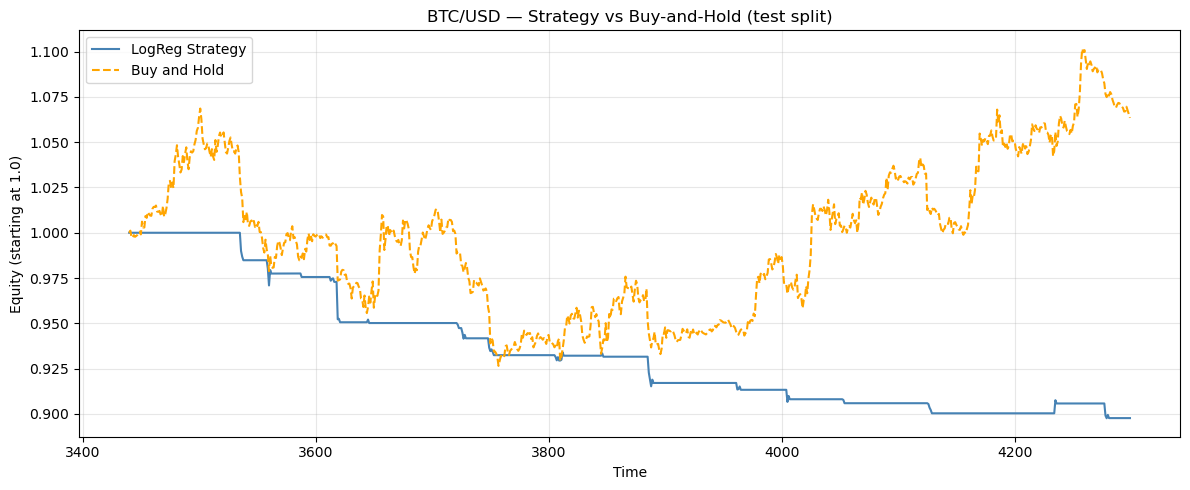

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
results["strategy_equity"].plot(ax=ax, label="LogReg Strategy", color="steelblue")
results["bnh_equity"].plot(ax=ax, label="Buy and Hold", color="orange", linestyle="--")
ax.set_title(f"{SYMBOL} — Strategy vs Buy-and-Hold (test split)")
ax.set_xlabel("Time")
ax.set_ylabel("Equity (starting at 1.0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Model

Persist the best estimator so `python -m bot --strategy logreg` can load it.

In [10]:
model_path = os.path.join(repo_root, "bot", "models", "logreg.pkl")
joblib.dump(best_model, model_path)

assert os.path.exists(model_path), f"Model file not found at {model_path}"
print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path):,} bytes")

Model saved to: /home/chenyang/Git/alpaca-ml-crypto/bot/models/logreg.pkl
File size: 1,311 bytes


## 9. Experiment Sweep (Symbols x Windows x Thresholds)

This section runs a compact robustness sweep:
- Multiple symbols
- Two non-overlapping 6-month windows
- Validation-based threshold tuning (then one final test evaluation)

You can edit `SYMBOLS` and `THRESHOLDS` to expand the search.

In [11]:
from datetime import datetime, timedelta, timezone
from alpaca.data.timeframe import TimeFrame


def run_symbol_window_experiment(symbol: str, start: datetime, end: datetime, thresholds: list[float]) -> dict:
    # 1) Fetch + feature engineering
    df_raw = fetch_bars_range(
        api_key,
        secret_key,
        symbol=symbol,
        timeframe=TimeFrame.Hour,
        start=start,
        end=end,
    )
    df_feat = compute_features(df_raw, extended=True)

    n = len(df_feat)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)
    df_train = df_feat.iloc[:train_end].copy()
    df_val = df_feat.iloc[train_end:val_end].copy()
    df_test = df_feat.iloc[val_end:].copy()

    # 2) Labels: thresholds derived only from training set
    X_train, y_train, lower, upper = make_labels(df_train, compute_thresholds=True)

    # 3) Train model (same approach as section 4)
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
    base_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
    grid = GridSearchCV(base_model, param_grid, cv=tscv, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    model = grid.best_estimator_

    # 4) Validation threshold sweep (optimize strategy total return after fees)
    val_prob = model.predict_proba(df_val[X_train.columns])[:, 1]
    best_threshold = None
    best_val_total_return = float("-inf")

    for th in thresholds:
        val_bt = df_val.copy()
        val_bt["signal"] = (val_prob > th).astype(int)
        val_results = run_backtest(val_bt)
        val_m, _ = compute_metrics(val_results)

        if val_m["total_return"] > best_val_total_return:
            best_val_total_return = val_m["total_return"]
            best_threshold = th

    # 5) Single test evaluation with chosen threshold
    test_prob = model.predict_proba(df_test[X_train.columns])[:, 1]
    test_bt = df_test.copy()
    test_bt["signal"] = (test_prob > best_threshold).astype(int)
    test_results = run_backtest(test_bt)
    test_m, bnh_m = compute_metrics(test_results)

    return {
        "symbol": symbol,
        "start": start.date().isoformat(),
        "end": end.date().isoformat(),
        "bars": n,
        "best_C": float(grid.best_params_["C"]),
        "best_threshold": float(best_threshold),
        "val_total_return": float(best_val_total_return),
        "test_total_return": float(test_m["total_return"]),
        "test_sharpe": float(test_m["sharpe_ratio"]),
        "test_max_drawdown": float(test_m["max_drawdown"]),
        "test_num_trades": int(test_m["num_trades"]),
        "test_win_rate": float(test_m["win_rate"]),
        "bnh_total_return": float(bnh_m["total_return"]),
        "bnh_sharpe": float(bnh_m["sharpe_ratio"]),
    }


# ---------- Sweep setup ----------
SYMBOLS = ["BTC/USD", "ETH/USD", "SOL/USD"]
THRESHOLDS = [x / 100 for x in range(45, 61)]  # 0.45 ... 0.60

now_utc = datetime.now(timezone.utc)
recent_end = now_utc
recent_start = recent_end - timedelta(days=180)
prev_end = recent_start
prev_start = prev_end - timedelta(days=180)

WINDOWS = [
    (recent_start, recent_end),
    (prev_start, prev_end),
]

rows = []
for sym in SYMBOLS:
    for start, end in WINDOWS:
        try:
            rows.append(run_symbol_window_experiment(sym, start, end, THRESHOLDS))
            print(f"DONE: {sym} | {start.date()} -> {end.date()}")
        except Exception as e:
            print(f"SKIP: {sym} | {start.date()} -> {end.date()} | {e}")

results_table = pd.DataFrame(rows).sort_values(["symbol", "start"]).reset_index(drop=True)

if not results_table.empty:
    display_table = results_table.copy()
    for col in ["val_total_return", "test_total_return", "test_max_drawdown", "test_win_rate", "bnh_total_return"]:
        display_table[col] = display_table[col].map("{:.2%}".format)
    display_table["test_sharpe"] = display_table["test_sharpe"].map("{:.3f}".format)
    display_table["bnh_sharpe"] = display_table["bnh_sharpe"].map("{:.3f}".format)
    display_table
else:
    print("No successful runs. Check credentials, symbol availability, or date windows.")

DONE: BTC/USD | 2025-10-21 -> 2026-04-19
DONE: BTC/USD | 2025-04-24 -> 2025-10-21
DONE: ETH/USD | 2025-10-21 -> 2026-04-19
DONE: ETH/USD | 2025-04-24 -> 2025-10-21
DONE: SOL/USD | 2025-10-21 -> 2026-04-19
DONE: SOL/USD | 2025-04-24 -> 2025-10-21


In [12]:
# Display results table
if not results_table.empty:
    display_table = results_table.copy()
    for col in ["val_total_return", "test_total_return", "test_max_drawdown", "test_win_rate", "bnh_total_return"]:
        display_table[col] = display_table[col].map("{:.2%}".format)
    display_table["test_sharpe"] = display_table["test_sharpe"].map("{:.3f}".format)
    display_table["bnh_sharpe"] = display_table["bnh_sharpe"].map("{:.3f}".format)
    display_table
else:
    print("No results to display")

In [14]:
print(f"Total rows: {len(results_table)}")
print("\nResults Table:")
print(results_table.to_string())

Total rows: 6

Results Table:
    symbol       start         end  bars  best_C  best_threshold  val_total_return  test_total_return  test_sharpe  test_max_drawdown  test_num_trades  test_win_rate  bnh_total_return  bnh_sharpe
0  BTC/USD  2025-04-24  2025-10-21  4300    0.01            0.60         -0.001650          -0.014862    -0.995627          -0.034809                4       0.500000         -0.060214   -1.516278
1  BTC/USD  2025-10-21  2026-04-19  4300    0.10            0.56          0.000000           0.000000     0.000000           0.000000                0       0.000000          0.062495    1.702860
2  ETH/USD  2025-04-24  2025-10-21  4301   10.00            0.60         -0.017618          -0.069878    -8.294325          -0.069878                8       0.000000         -0.143216   -2.206913
3  ETH/USD  2025-10-21  2026-04-19  4299    0.01            0.54          0.000000           0.000000     0.000000           0.000000                0       0.000000          0.115465   